## Crop Recommendation

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("Crop_District_Level.csv")

In [9]:
# top 5 rows of dataset

df.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label,district
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,ryk
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,bahawalnagar
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,bwp
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,rajanpur
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,digikhan


In [10]:
# checking null values

df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0
district,0


In [11]:
# checking duplicates

df.duplicated().sum()

np.int64(0)

### EDA

In [12]:
# dataset shape

df.shape

(2200, 9)

In [13]:
# dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
 8   district     2200 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 154.8+ KB


In [71]:
# describe dataset

df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [15]:
df.describe(include= 'object')

,label,district
count,2200,2200
unique,13,39
top,maize,gujrat
freq,300,176


checking class balance/imbalance

In [16]:
# target value counts

df['label'].value_counts()

,count
label,
maize,300
sugarcane,300
wheat,300
cotton,300
rice,200
millets,100
pulses,100
blackgram,100
mungbean,100


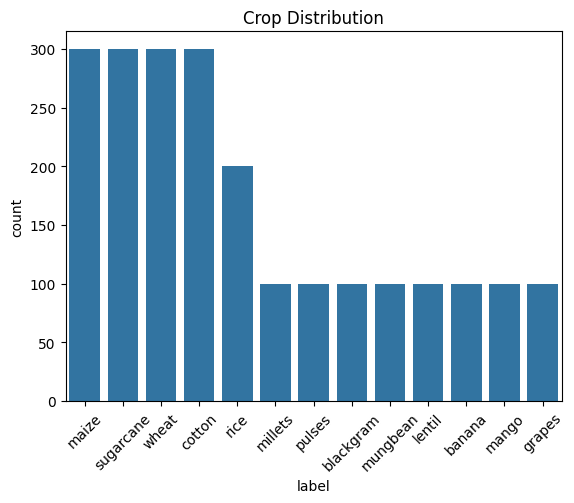

In [35]:
# plotting 'label' value counts

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Crop Distribution")
plt.show()

<Axes: >

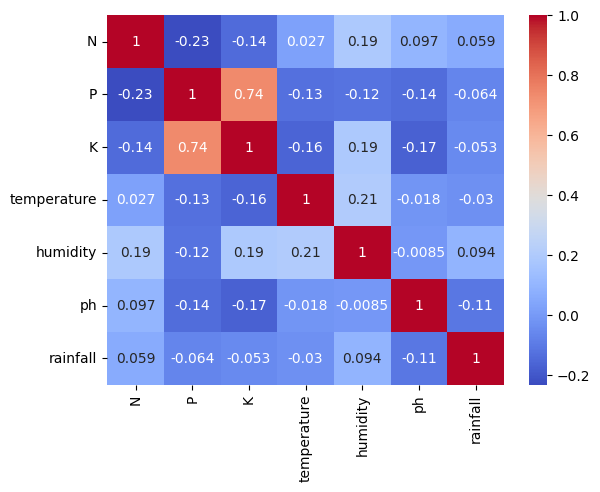

In [17]:
# correlation heatmap

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot= True, cmap='coolwarm')

In [120]:
print('Correlation Matrix:')
display(numeric_df.corr())

Correlation Matrix:


,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


<Axes: >

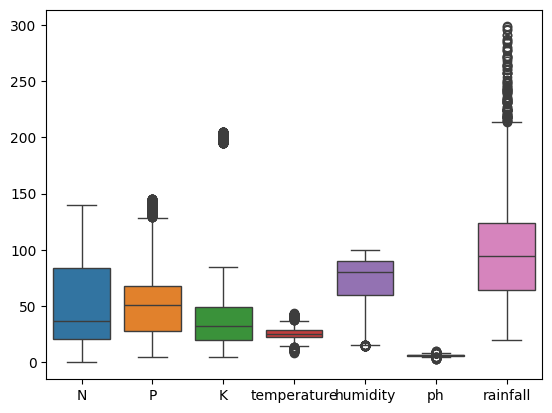

In [18]:
# boxplot

sns.boxplot(data=df)

### Outlier Detection

In [19]:
# checking outliers with quartile Q1 and Q3

numeric_df_for_outliers = df.select_dtypes(include=['number'])

Q1 = numeric_df_for_outliers.quantile(0.25)
Q3 = numeric_df_for_outliers.quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers for each numerical column
outliers = numeric_df_for_outliers[( (numeric_df_for_outliers < lower_bound) | (numeric_df_for_outliers > upper_bound) ).any(axis=1) ]

print("Outliers based on IQR method:")
print(outliers.head())

Outliers based on IQR method:
    N   P   K  temperature   humidity        ph    rainfall
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340
5  69  37  42    23.058049  83.370118  7.073454  251.055000


In [100]:
outliers.value_counts()

N   P    K    temperature  humidity   ph        rainfall  
91  36   45   24.443455    82.454326  5.950648  267.976195    1
90  46   42   23.978982    81.450616  7.502834  250.083234    1
    44   38   23.835095    83.883871  7.473134  241.201351    1
89  54   38   24.515881    83.535216  6.685346  230.446236    1
88  55   45   24.635449    80.413630  7.730368  253.720278    1
                                                             ..
0   145  205  21.225034    90.098778  5.520783  113.976046    1
    137  195  22.435902    80.186121  6.329500  65.397317     1
    133  200  23.672877    90.493557  5.708419  104.229803    1
    123  205  22.027754    92.961295  5.790993  121.134918    1
    55   25   28.174894    43.667230  4.524172  45.781728     1
Name: count, Length: 432, dtype: int64

In [119]:
# count the total number of outliers

total_outliers = outliers.shape[0]
print(f"Total number of outliers are, {total_outliers}")

Total number of outliers are, 432


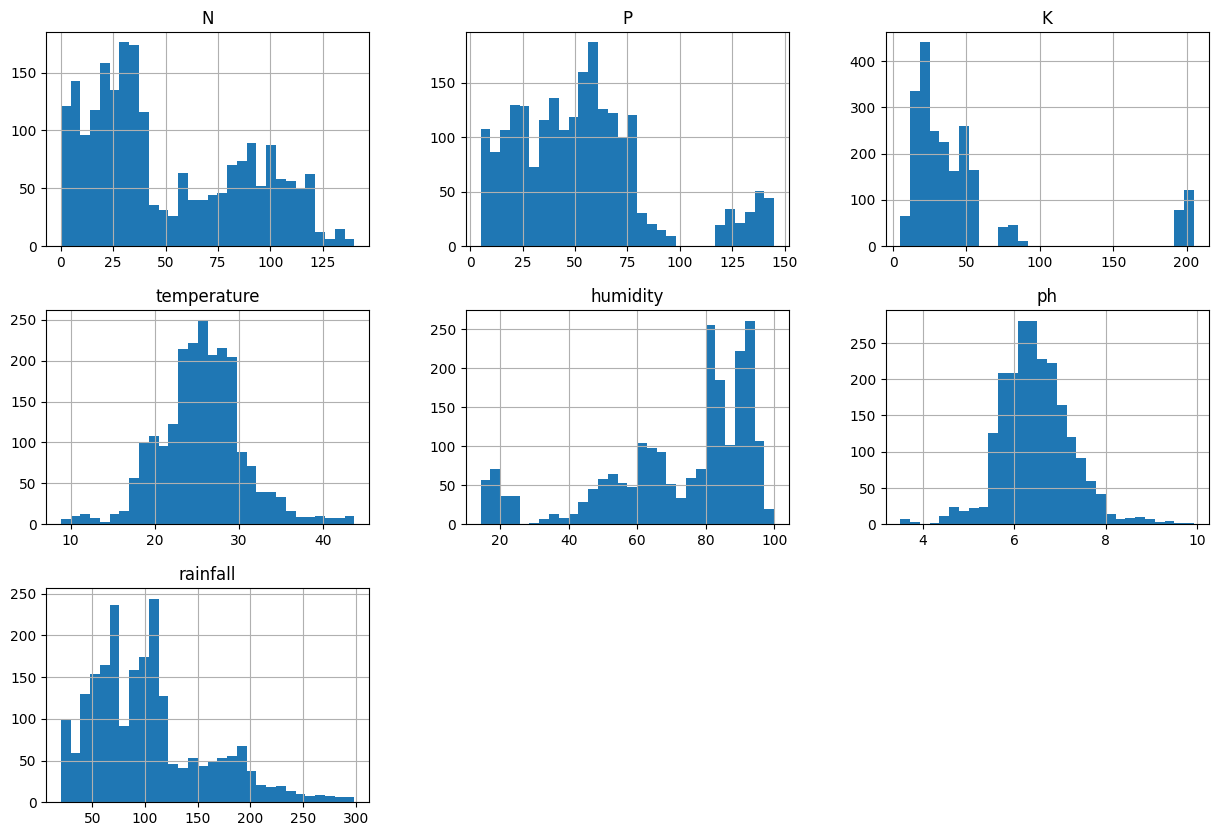

In [37]:
# histogram for distribution and skewness

df[numeric_df_for_outliers.columns].hist(
    figsize=(15,10),
    bins=30
)

# plt.tight_layout()
plt.show()

boxplots for all numerical features against the crop 'label' to see their distributions

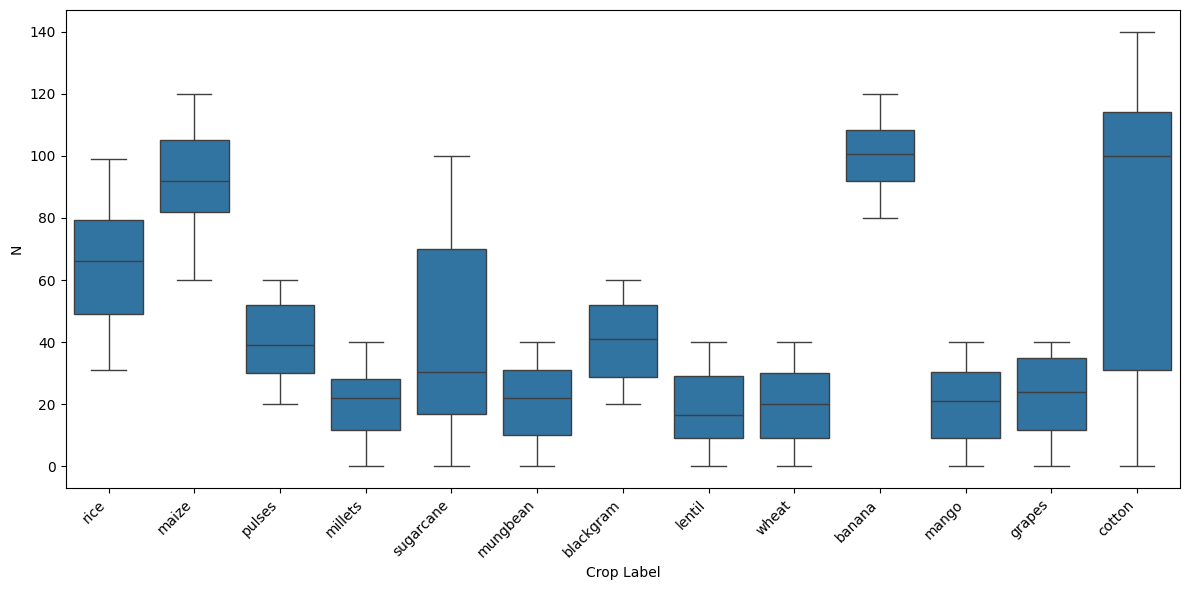

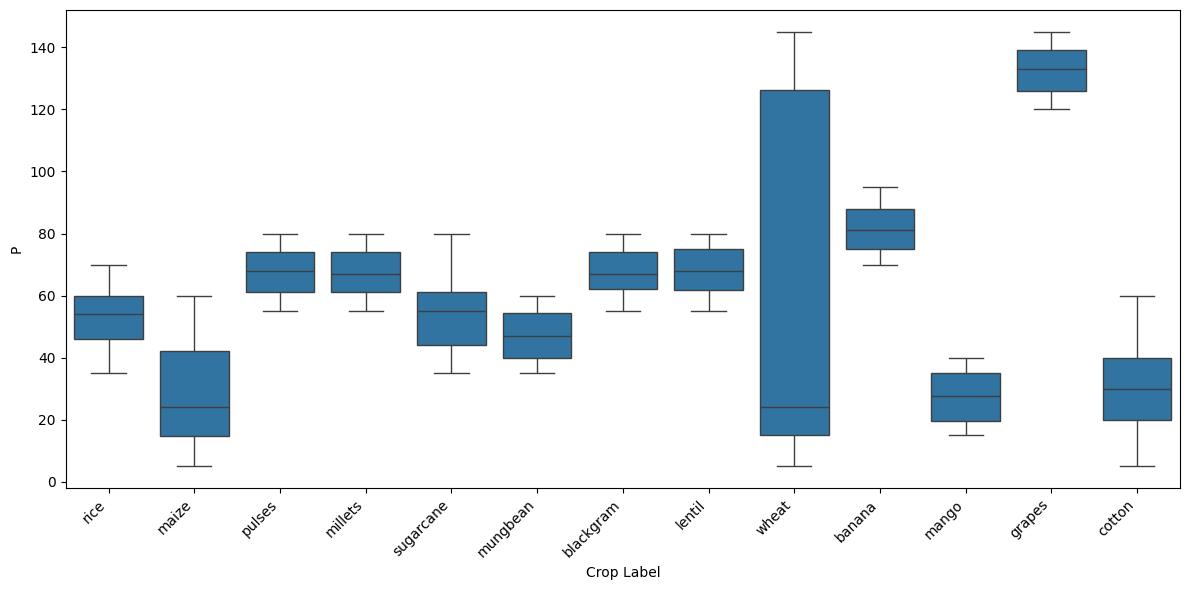

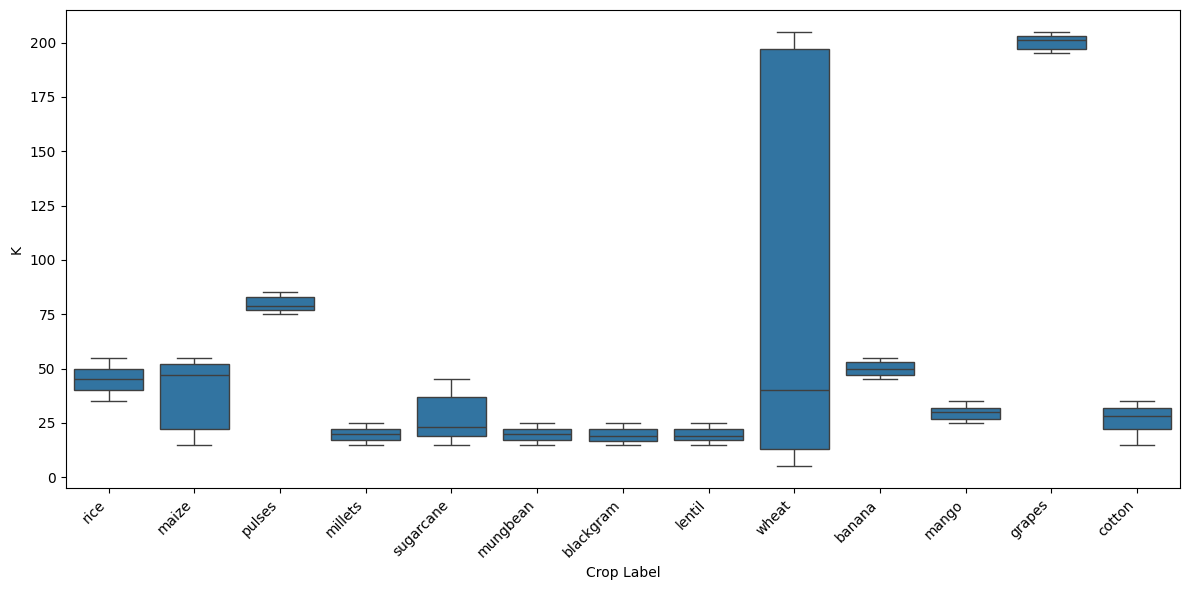

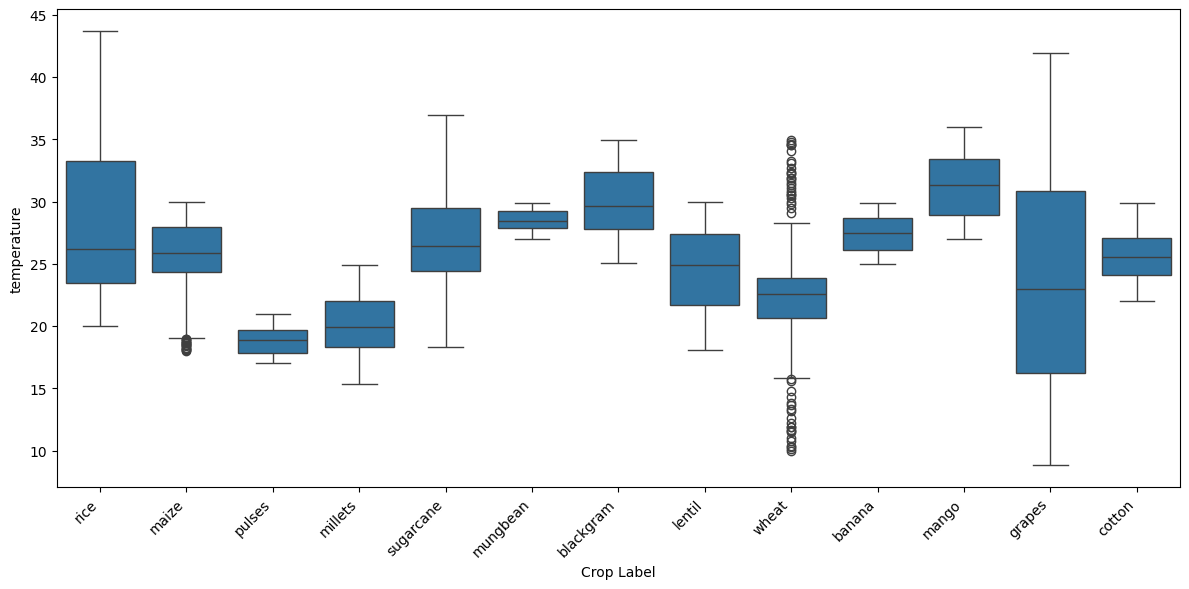

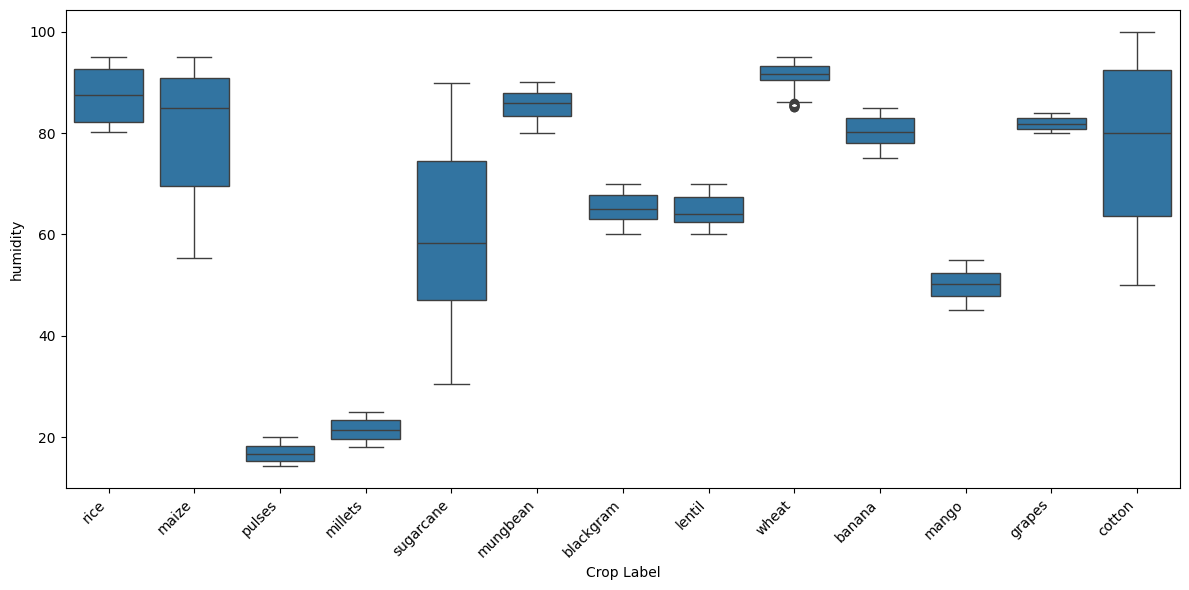

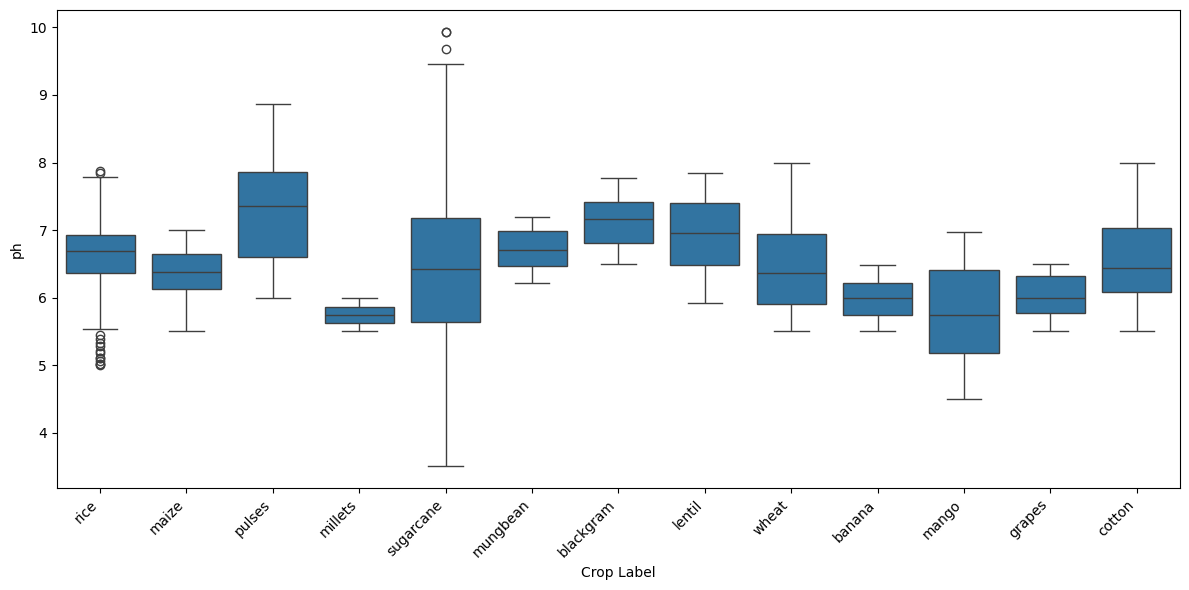

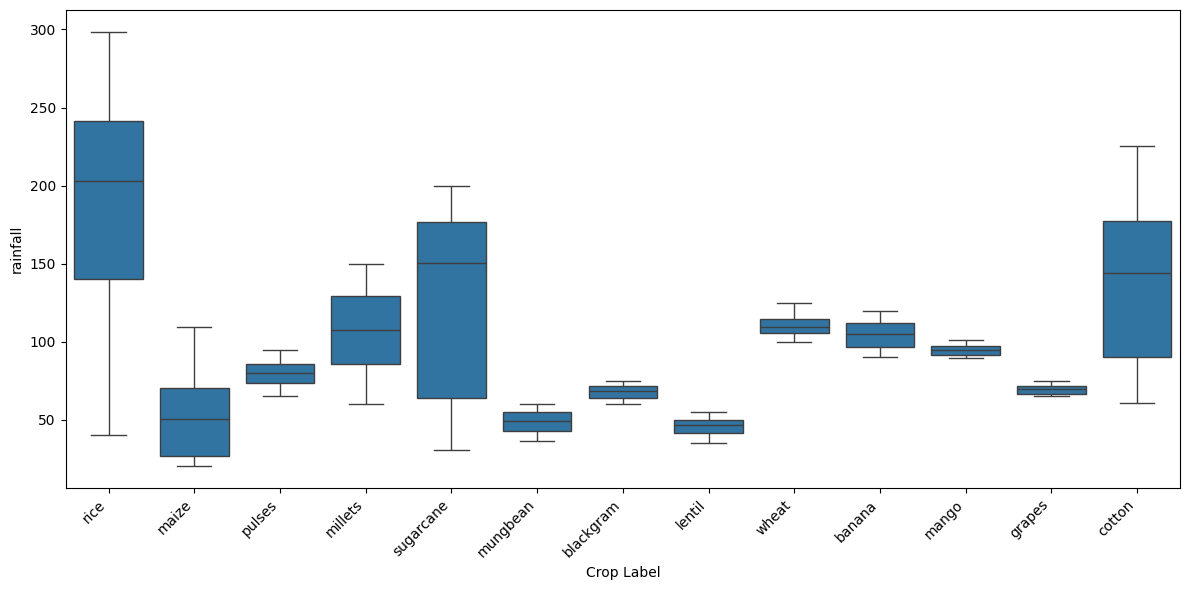

In [95]:
numerical_features = numeric_df_for_outliers.columns

for feature in numerical_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='label', y=feature)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Crop Label')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [118]:
outlier_count = {}

for column in numeric_df_for_outliers.columns:
    lower = lower_bound[column]
    upper = upper_bound[column]

    count = (
        (numeric_df_for_outliers[column] < lower) |(numeric_df_for_outliers[column] > upper)).sum()

    outlier_count[column] = count

pd.DataFrame.from_dict(
    outlier_count,
    orient="index",
    columns=["Outlier Count"]
)

,Outlier Count
N,0
P,138
K,200
temperature,86
humidity,30
ph,57
rainfall,100


In [117]:
outliers.sample(5)

,N,P,K,temperature,humidity,ph,rainfall
596,22,51,16,27.965837,61.349001,8.639586,70.104721
1210,25,130,197,39.707722,82.685935,5.554832,74.915062
18,77,38,36,21.865252,80.192301,5.953933,224.555017
1534,24,142,202,22.537797,91.481358,5.710820,101.847477
1251,12,142,203,31.311598,82.564070,5.972851,65.010953


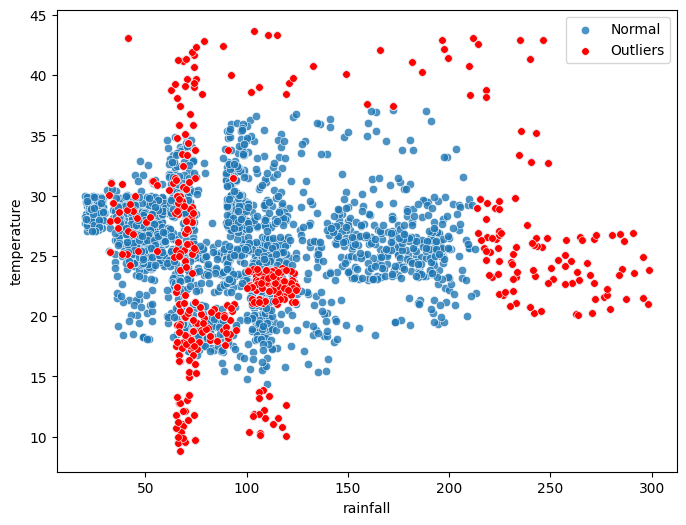

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="rainfall",
    y="temperature",
    alpha=0.8,
    label="Normal"
)

sns.scatterplot(
    data=outliers,
    x="rainfall",
    y="temperature",
    color="red",
    s=30,
    label="Outliers"
)

plt.legend()
plt.show()

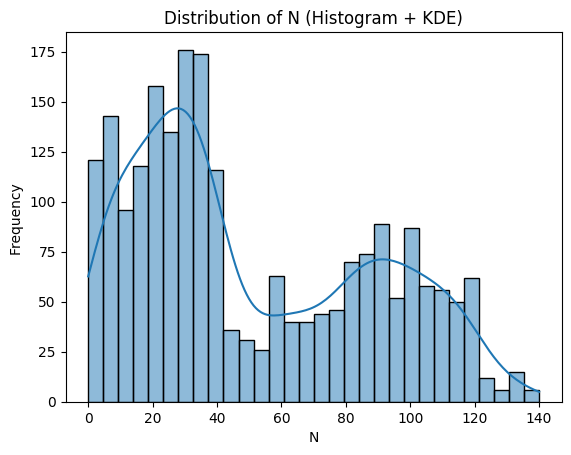

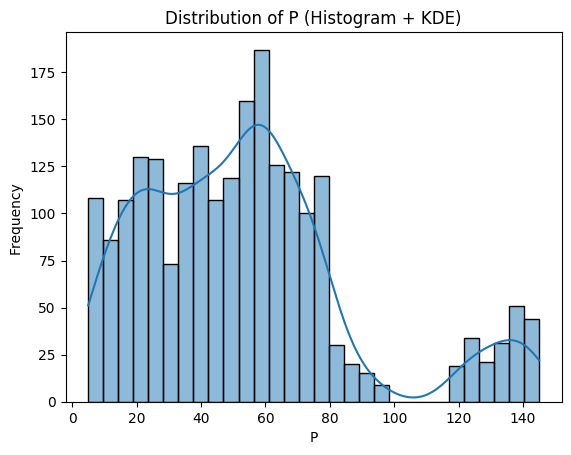

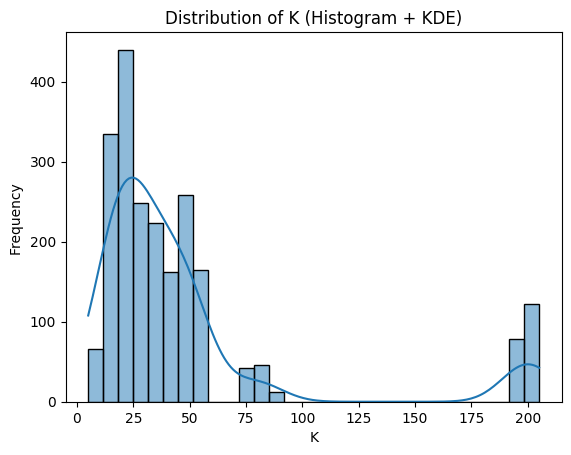

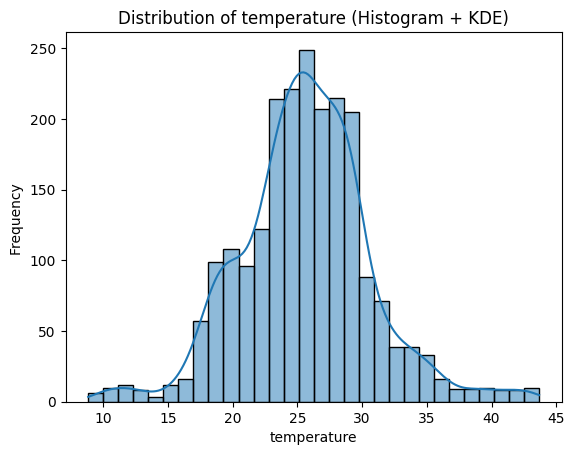

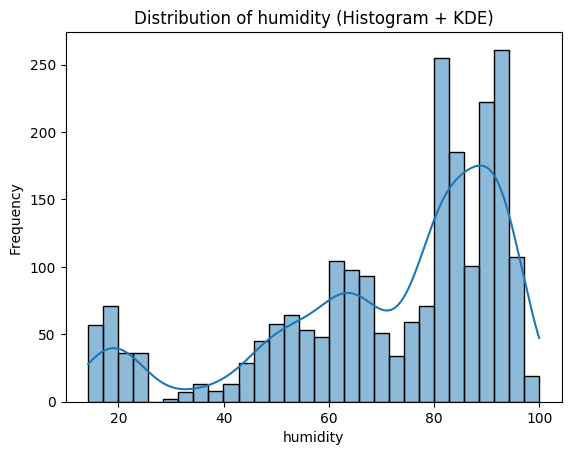

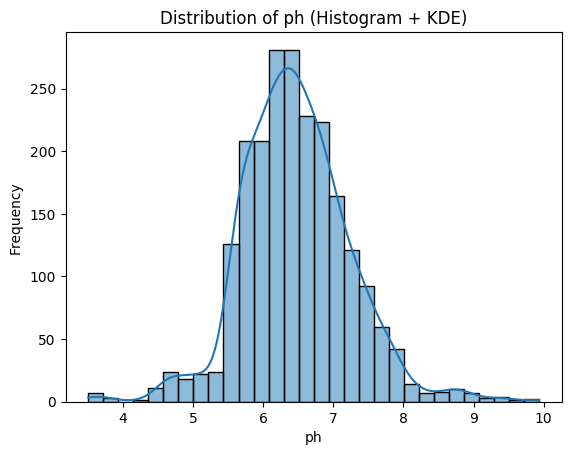

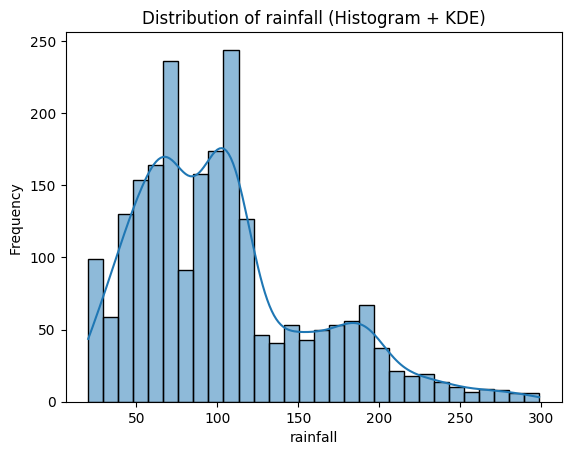

In [124]:
for feature in numeric_df.columns:
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature} (Histogram + KDE)')
    plt.xlabel(feature)
    plt.ylabel('Frequency ')
    plt.show()